# 第6节：对抗攻击行为分析与可视化

本节目标：

1. 对比不同攻击方法（FGSM / PGD / CW）对模型输出行为的影响：
   - 预测标签变化、置信度变化、错误类型分布
2. 从“特征空间”视角理解对抗样本：
   - 同一样本在攻击前后，在 embedding 空间的位置如何移动？
   - 类中心（class centroid）是否发生系统性偏移？
   - 最近邻结构是否被破坏？
3. 掌握常用可视化手段：
   - 原图 / 扰动 / 对抗图
   - 误分类统计、置信度直方图
   - PCA / t-SNE 的 2D 特征散点
   - 类中心漂移向量、样本位移向量
   - 最近邻保持率（neighbor preservation）


## 0. 路径与环境约定

统一使用：

```python
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
```

输入统一归一化到 `[0,1]`，便于定义 ε。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('torch:', torch.__version__, 'cuda available:', torch.cuda.is_available())

device = torch.device('cpu')


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\data
torch: 2.10.0+cpu cuda available: False


## 1. 数据加载

支持：
- `data/digits.npz`（X, y）
- `data/X.npy` + `data/y.npy`
- 回退：sklearn digits

并将输入归一化到 `[0,1]`。

In [2]:
def load_course_data():
    npz_path = DATA_DIR / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path}'

    x_npy = DATA_DIR / 'X.npy'
    y_npy = DATA_DIR / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data()
print(info)
print('X:', X.shape, 'y:', y.shape)

x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

print('range:', float(X01.min()), float(X01.max()))


Loaded local NPZ: C:\Users\wingl\PycharmProjects\adversarialmeow\data\digits.npz
X: (1797, 64) y: (1797,)
range: 0.0 1.0


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


## 2. 训练一个带“可抽取特征”的模型

为了分析特征空间，我们显式定义一个 `feature()`：
- `feature(x)` 输出隐藏层 embedding
- `forward(x)` 输出 logits

这样我们可以对同一批样本比较：
- clean feature
- adversarial feature


In [5]:
class MLPFeat(nn.Module):
    def __init__(self, in_dim=64, hidden=128, emb_dim=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, emb_dim)
        self.fc3 = nn.Linear(emb_dim, num_classes)

    def feature(self, x):
        x = F.relu(self.fc1(x))
        z = F.relu(self.fc2(x))
        return z

    def forward(self, x):
        z = self.feature(x)
        return self.fc3(z)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            yb = y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

model = MLPFeat().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_model(model, X, y, epochs=12, batch=256):
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb = X[idx]
            yb = y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train acc={accuracy(model, X, y):.4f} | test acc={accuracy(model, X_test_t, y_test_t):.4f}')

train_model(model, X_train_t, y_train_t, epochs=20)
print('Clean test acc:', accuracy(model, X_test_t, y_test_t))


Epoch 01 | train acc=0.2146 | test acc=0.1956
Epoch 02 | train acc=0.5442 | test acc=0.5311
Epoch 04 | train acc=0.7045 | test acc=0.6800
Epoch 06 | train acc=0.7610 | test acc=0.7489
Epoch 08 | train acc=0.8315 | test acc=0.8067
Epoch 10 | train acc=0.8834 | test acc=0.8489
Epoch 12 | train acc=0.9027 | test acc=0.8711
Epoch 14 | train acc=0.9243 | test acc=0.9000
Epoch 16 | train acc=0.9354 | test acc=0.9133
Epoch 18 | train acc=0.9421 | test acc=0.9267
Epoch 20 | train acc=0.9465 | test acc=0.9333
Clean test acc: 0.9333333333333333


## 3. 生成对抗样本（FGSM / PGD / CW 教学版）

为保证本节独立可运行，这里内置第5节的攻击实现：
- FGSM（L∞ 单步）
- PGD（L∞ 多步 + 投影）
- CW（L2 优化式教学版）


In [7]:
def fgsm_attack(model, x, y, eps=0.1):
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv + eps * torch.sign(grad)
    return torch.clamp(x_adv.detach(), 0.0, 1.0)

def pgd_attack(model, x, y, eps=0.1, alpha=0.02, steps=20, random_start=True):
    model.eval()
    x0 = x.detach()
    x_adv = x0.clone()
    if random_start:
        x_adv = x_adv + torch.empty_like(x_adv).uniform_(-eps, eps)
        x_adv = torch.clamp(x_adv, 0.0, 1.0)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv + alpha * torch.sign(grad)
        x_adv = torch.max(torch.min(x_adv, x0 + eps), x0 - eps)
        x_adv = torch.clamp(x_adv.detach(), 0.0, 1.0)
    return x_adv

def cw_l2_attack(model, x, y, c=3.0, kappa=0.0, lr=0.03, steps=200):
    model.eval()
    x0 = x.detach()
    eps = 1e-6
    x_clamped = torch.clamp(x0, eps, 1-eps)
    w = torch.atanh(2 * x_clamped - 1).detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([w], lr=lr)

    def f_untargeted(logits, y_true):
        B = logits.shape[0]
        logit_y = logits[torch.arange(B), y_true]
        mask = torch.ones_like(logits, dtype=torch.bool)
        mask[torch.arange(B), y_true] = False
        max_other = logits.masked_fill(~mask, -1e9).max(dim=1).values
        return torch.clamp(logit_y - max_other + kappa, min=0.0)

    for i in range(steps):
        x_adv = 0.5 * (torch.tanh(w) + 1.0)
        logits = model(x_adv)
        l2 = ((x_adv - x0) ** 2).sum(dim=1)
        loss = (l2 + c * f_untargeted(logits, y)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        if (i+1) % 50 == 0 or i == 0:
            with torch.no_grad():
                succ = float((logits.argmax(dim=1) != y).float().mean().item())
            print(f'CW step {i+1:03d} | loss={loss.item():.4f} | succ={succ:.3f}')

    x_adv = 0.5 * (torch.tanh(w) + 1.0)
    return x_adv.detach()


## 4. 可视化工具箱：原图/扰动/对抗图 + 置信度变化

我们先定义几个通用可视化函数：
- show_triplet：展示原图、扰动、对抗图
- confidence_change：展示攻击前后 top-1 置信度与分布


In [8]:
def show_triplet(x, y, x_adv, model, title='triplet', max_show=6):
    model.eval()
    with torch.no_grad():
        p0 = model(x).argmax(dim=1).cpu().numpy()
        p1 = model(x_adv).argmax(dim=1).cpu().numpy()
        s0 = F.softmax(model(x), dim=1).max(dim=1).values.cpu().numpy()
        s1 = F.softmax(model(x_adv), dim=1).max(dim=1).values.cpu().numpy()

    x0 = x.cpu().numpy()
    xa = x_adv.cpu().numpy()
    d  = xa - x0
    B = min(max_show, len(x0))

    plt.figure(figsize=(12, 6))
    for i in range(B):
        ax1 = plt.subplot(3, B, i+1)
        ax1.imshow(x0[i].reshape(8,8), cmap='gray')
        ax1.set_title(f'orig y={int(y[i])}\np={int(p0[i])} conf={s0[i]:.2f}')
        ax1.axis('off')

        ax2 = plt.subplot(3, B, B+i+1)
        ax2.imshow(d[i].reshape(8,8), cmap='gray')
        ax2.set_title('perturb')
        ax2.axis('off')

        ax3 = plt.subplot(3, B, 2*B+i+1)
        ax3.imshow(xa[i].reshape(8,8), cmap='gray')
        ax3.set_title(f'adv p={int(p1[i])}\nconf={s1[i]:.2f}')
        ax3.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_confidence_hist(model, x, x_adv, title='confidence'):
    model.eval()
    with torch.no_grad():
        c0 = F.softmax(model(x), dim=1).max(dim=1).values.cpu().numpy()
        c1 = F.softmax(model(x_adv), dim=1).max(dim=1).values.cpu().numpy()

    plt.figure(figsize=(6,4))
    plt.hist(c0, bins=20, alpha=0.7, label='clean')
    plt.hist(c1, bins=20, alpha=0.7, label='adv')
    plt.title(title)
    plt.xlabel('top-1 confidence')
    plt.ylabel('count')
    plt.legend()
    plt.show()


## 5. 输出行为分析：不同攻击下的准确率/成功率/错误结构

我们统一统计：
- clean acc
- adv acc
- success rate（untargeted：pred_adv != y）
- 错误从哪些真实类流向哪些预测类（混淆矩阵/错误流）


In [9]:
from sklearn.metrics import confusion_matrix

def eval_attack(model, X, y, make_adv_fn, batch=256):
    model.eval()
    with torch.no_grad():
        pred_clean = model(X).argmax(dim=1)
    clean_acc = float((pred_clean == y).float().mean().item())

    preds_adv = []
    y_all = []
    for i in range(0, len(X), batch):
        xb = X[i:i+batch]
        yb = y[i:i+batch]
        x_adv = make_adv_fn(xb, yb)
        with torch.no_grad():
            pa = model(x_adv).argmax(dim=1)
        preds_adv.append(pa.cpu().numpy())
        y_all.append(yb.cpu().numpy())

    pred_adv = np.concatenate(preds_adv)
    y_np = np.concatenate(y_all)
    adv_acc = float(np.mean(pred_adv == y_np))
    succ = float(np.mean(pred_adv != y_np))
    cm = confusion_matrix(y_np, pred_adv, labels=np.unique(y_np))
    return clean_acc, adv_acc, succ, cm, pred_adv

def plot_cm(cm, title='confusion'):
    plt.figure(figsize=(5.5,5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.colorbar()
    plt.show()


Clean acc: 0.9333333333333333
FGSM eps=0.1 | adv_acc=0.5533 | succ=0.4467


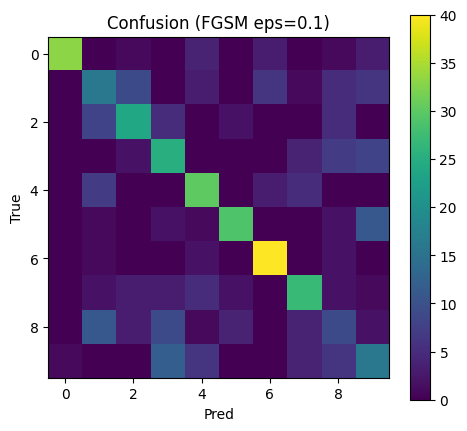

PGD  eps=0.1 | adv_acc=0.5222 | succ=0.4778


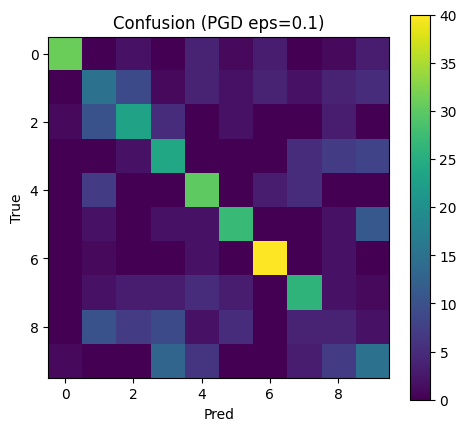

In [10]:
# 配置三个攻击
eps = 0.10

def make_fgsm(xb, yb):
    return fgsm_attack(model, xb, yb, eps=eps)

def make_pgd(xb, yb):
    return pgd_attack(model, xb, yb, eps=eps, alpha=0.02, steps=20, random_start=True)

def make_cw(xb, yb):
    # CW 更慢，教学中可限制 batch
    return cw_l2_attack(model, xb, yb, c=3.0, lr=0.03, steps=150)

clean_acc0 = accuracy(model, X_test_t, y_test_t)
print('Clean acc:', clean_acc0)

c1, a1, s1, cm1, pred1 = eval_attack(model, X_test_t, y_test_t, make_fgsm)
print(f'FGSM eps={eps} | adv_acc={a1:.4f} | succ={s1:.4f}')
plot_cm(cm1, f'Confusion (FGSM eps={eps})')

c2, a2, s2, cm2, pred2 = eval_attack(model, X_test_t, y_test_t, make_pgd)
print(f'PGD  eps={eps} | adv_acc={a2:.4f} | succ={s2:.4f}')
plot_cm(cm2, f'Confusion (PGD eps={eps})')


### CW 演示：为保证课堂运行速度，只对一小批样本做行为分析

In [11]:
idxs = torch.arange(0, 64, device=device)
x_small = X_test_t[idxs]
y_small = y_test_t[idxs]

x_cw = make_cw(x_small, y_small)
with torch.no_grad():
    pred_cw = model(x_cw).argmax(dim=1)
    adv_acc_cw = float((pred_cw == y_small).float().mean().item())
    succ_cw = float((pred_cw != y_small).float().mean().item())

print(f'CW (small batch) | adv_acc={adv_acc_cw:.4f} | succ={succ_cw:.4f}')


CW step 001 | loss=9.7483 | succ=0.062
CW step 050 | loss=1.1197 | succ=0.953
CW step 100 | loss=0.8111 | succ=0.891
CW step 150 | loss=0.7386 | succ=0.922
CW (small batch) | adv_acc=0.0938 | succ=0.9062


## 6. 可视化：原图/扰动/对抗图 + 置信度直方图

对比 FGSM vs PGD（同一 ε），观察：
- 扰动模式是否更“结构化”？
- 对抗后置信度分布是否更极端（或者更不稳定）？

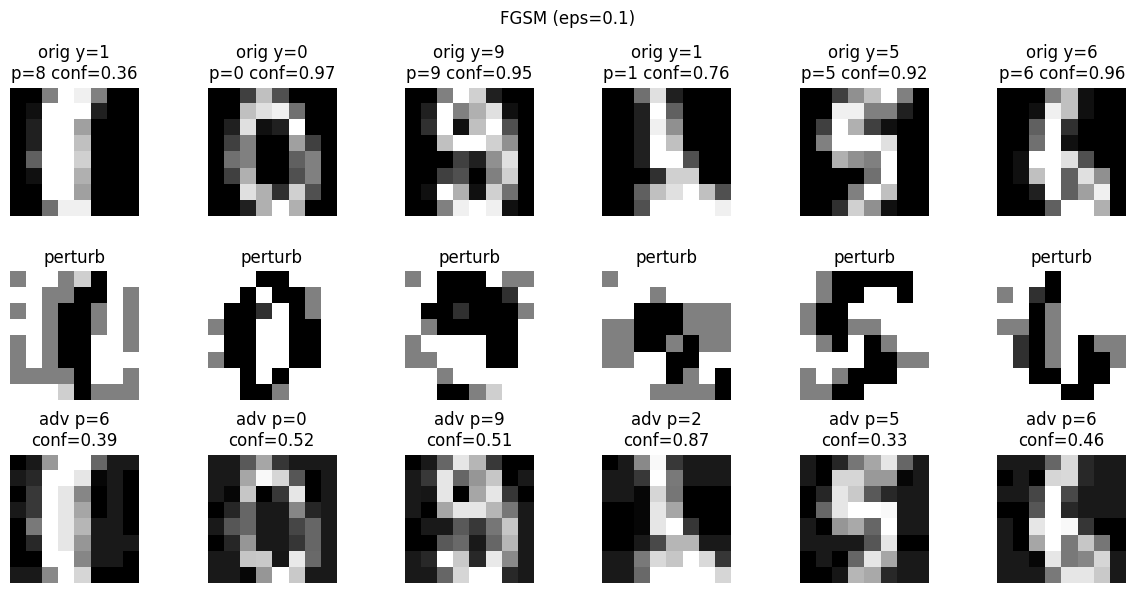

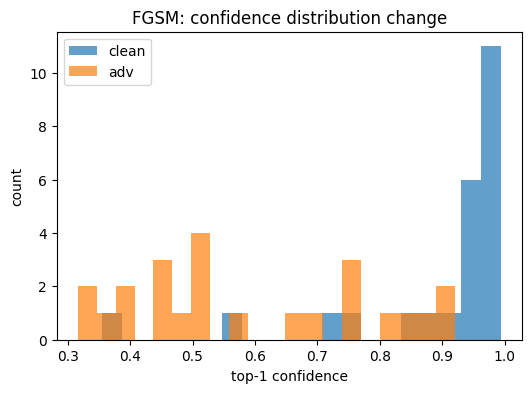

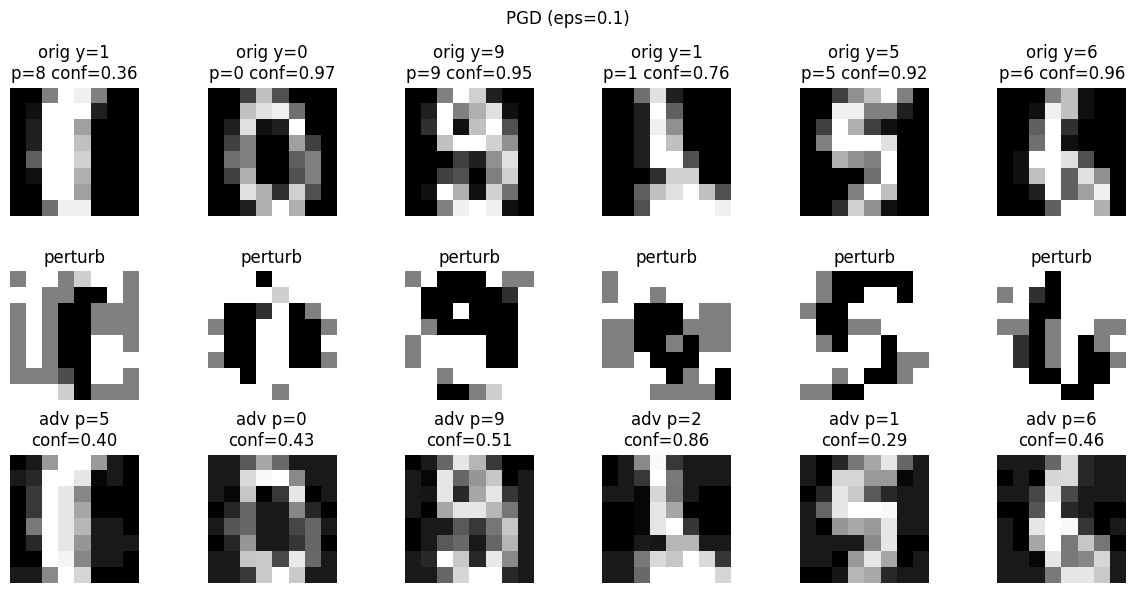

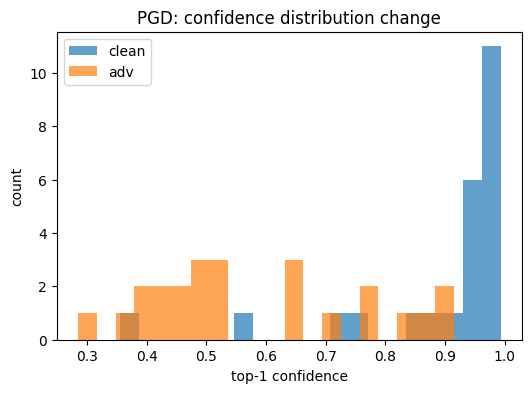

In [12]:
idxs = torch.arange(0, 24, device=device)
x0 = X_test_t[idxs]
y0 = y_test_t[idxs]

x_f = make_fgsm(x0, y0)
x_p = make_pgd(x0, y0)

show_triplet(x0, y0.cpu().numpy(), x_f, model, title=f'FGSM (eps={eps})')
plot_confidence_hist(model, x0, x_f, title='FGSM: confidence distribution change')

show_triplet(x0, y0.cpu().numpy(), x_p, model, title=f'PGD (eps={eps})')
plot_confidence_hist(model, x0, x_p, title='PGD: confidence distribution change')


## 7. 特征空间影响分析（Embedding Space）

我们对同一批样本抽取 embedding：
- z_clean = feature(x)
- z_adv   = feature(x_adv)

并用 PCA 映射到二维，观察：
- 同一个样本的位移向量（clean→adv）
- 不同类是否发生混叠（class overlap）
- FGSM / PGD 的位移规模是否不同


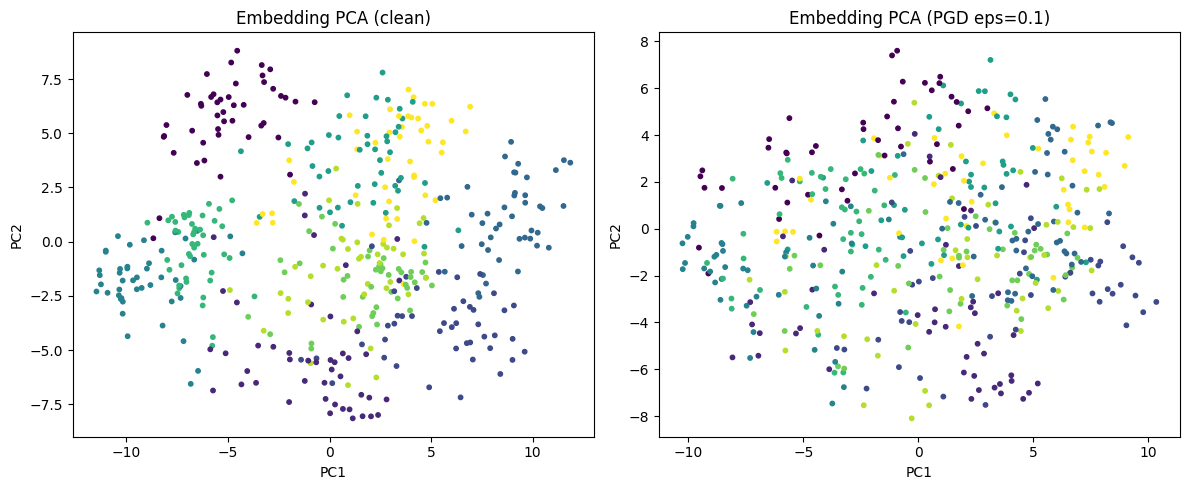

In [13]:
from sklearn.decomposition import PCA

def get_features(model, X, batch=256):
    model.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            z = model.feature(xb)
            feats.append(z.cpu().numpy())
    return np.concatenate(feats, axis=0)

# 选一部分样本做清晰可视化
N = 600
X_vis = X_test_t[:N]
y_vis = y_test_t[:N]

X_vis_f = make_fgsm(X_vis, y_vis)
X_vis_p = make_pgd(X_vis, y_vis)

z_clean = get_features(model, X_vis)
z_fgsm  = get_features(model, X_vis_f)
z_pgd   = get_features(model, X_vis_p)

pca = PCA(n_components=2, random_state=42)
Z2_clean = pca.fit_transform(z_clean)
Z2_fgsm  = pca.transform(z_fgsm)
Z2_pgd   = pca.transform(z_pgd)

y_np = y_vis.cpu().numpy()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(Z2_clean[:,0], Z2_clean[:,1], s=10, c=y_np)
plt.title('Embedding PCA (clean)')
plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1,2,2)
plt.scatter(Z2_pgd[:,0], Z2_pgd[:,1], s=10, c=y_np)
plt.title(f'Embedding PCA (PGD eps={eps})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()


### 7.1 样本位移向量可视化（clean→adv）

为了避免图太乱，我们随机抽取一小部分点画箭头。
箭头越长，表示对抗样本在特征空间的“位移”越大。

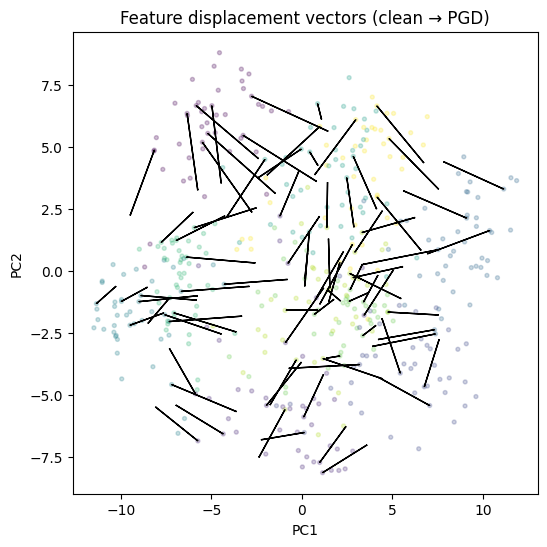

In [14]:
rng = np.random.default_rng(42)
sel = rng.choice(len(Z2_clean), size=80, replace=False)

plt.figure(figsize=(6,6))
plt.scatter(Z2_clean[:,0], Z2_clean[:,1], s=8, c=y_np, alpha=0.25)

for i in sel:
    x0, y0p = Z2_clean[i]
    x1, y1p = Z2_pgd[i]
    plt.arrow(x0, y0p, x1-x0, y1p-y0p, head_width=0.02, length_includes_head=True)

plt.title('Feature displacement vectors (clean → PGD)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


### 7.2 类中心漂移（class centroid shift）

对每个类别计算特征中心：
- μ_clean(k)
- μ_adv(k)

观察：
- 某些类别中心在攻击下更容易被推向其它类别区域
- 这类“系统性漂移”会导致类别混淆结构发生变化

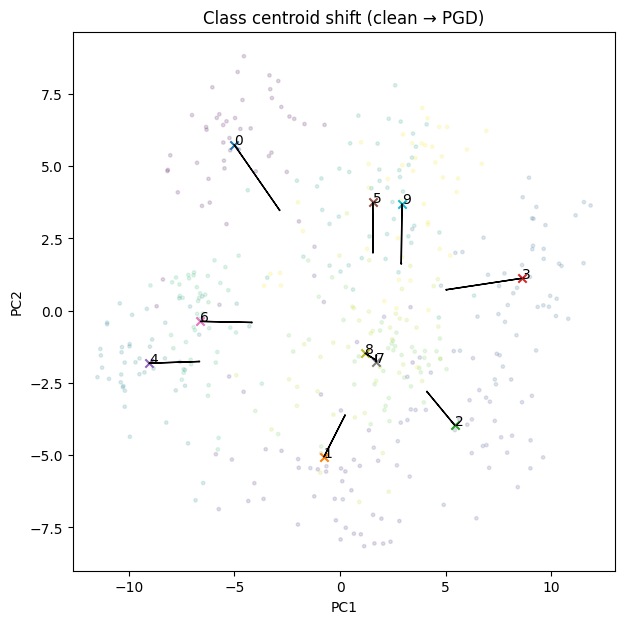

In [15]:
def class_centroids(Z2, y_np, num_classes=10):
    cents = []
    for k in range(num_classes):
        idx = np.where(y_np == k)[0]
        if len(idx) == 0:
            cents.append([np.nan, np.nan])
        else:
            cents.append(Z2[idx].mean(axis=0))
    return np.array(cents)

cent_clean = class_centroids(Z2_clean, y_np)
cent_fgsm  = class_centroids(Z2_fgsm, y_np)
cent_pgd   = class_centroids(Z2_pgd, y_np)

plt.figure(figsize=(7,7))
plt.scatter(Z2_clean[:,0], Z2_clean[:,1], s=6, c=y_np, alpha=0.15)

for k in range(10):
    x0, y0p = cent_clean[k]
    x1, y1p = cent_pgd[k]
    plt.scatter([x0],[y0p], marker='x')
    plt.text(x0, y0p, str(k))
    if not (np.isnan(x0) or np.isnan(x1)):
        plt.arrow(x0, y0p, x1-x0, y1p-y0p, head_width=0.03, length_includes_head=True)

plt.title('Class centroid shift (clean → PGD)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


## 8. 最近邻保持率：攻击是否破坏局部结构？

直觉：
- 在 embedding 空间里，一个样本的近邻通常是同类/相似样本
- 对抗攻击可能让样本移出原来的局部邻域

我们定义一个简单指标：
- 对每个样本，在 clean 特征空间找 top-k 近邻
- 在 adv 特征空间也找 top-k 近邻
- 计算两者集合重合比例，平均得到保持率


In [16]:
from sklearn.neighbors import NearestNeighbors

def neighbor_preservation(Z_clean, Z_adv, k=10):
    nn_clean = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(Z_clean)
    nn_adv   = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(Z_adv)

    idx_clean = nn_clean.kneighbors(Z_clean, return_distance=False)[:, 1:]  # 去掉自身
    idx_adv   = nn_adv.kneighbors(Z_adv,   return_distance=False)[:, 1:]

    overlap = []
    for i in range(len(Z_clean)):
        a = set(idx_clean[i].tolist())
        b = set(idx_adv[i].tolist())
        overlap.append(len(a.intersection(b)) / k)
    return float(np.mean(overlap))

pres_f = neighbor_preservation(z_clean, z_fgsm, k=10)
pres_p = neighbor_preservation(z_clean, z_pgd,  k=10)

print('Neighbor preservation (clean vs FGSM):', round(pres_f, 4))
print('Neighbor preservation (clean vs PGD) :', round(pres_p, 4))


Neighbor preservation (clean vs FGSM): 0.516
Neighbor preservation (clean vs PGD) : 0.5109


## 9. 可视化手段介绍：课堂讲解建议

1) **图像级**：原图/扰动/对抗图
- 讲清：对抗扰动在像素空间很小，但在模型特征空间可能造成巨大位移

2) **输出级**：置信度分布与错误结构
- 讲清：错误不仅是变错，还包括“错得很自信”与“错得很不稳定”

3) **特征空间**：PCA/t-SNE
- 讲清：对抗样本并非随机噪声，它沿着损失地形与决策边界方向移动

4) **结构指标**：类中心漂移、最近邻保持率
- 讲清：攻击能破坏局部结构与类簇分离，解释混淆矩阵变化

可选拓展：
- t-SNE（更能展示簇结构，但更慢且参数敏感）
- UMAP（需要额外包，离线课包未必包含）


## 10. 本节练习

1) 改变 ε（0.02/0.05/0.1/0.2），比较 FGSM 与 PGD 的：
- adv accuracy
- 特征空间位移均值
- 最近邻保持率

2) 将 PCA 换成 t-SNE（可选）：观察簇结构是否更清晰。

3) 选择某一类（例如数字 3），只画该类在 clean→adv 的位移向量，分析其更易混淆到哪些类。
